In [1]:
import sys
import os

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Read Data

In [9]:
df_sig = pd.read_csv("data_files/otm&brm_1767.csv")
df_bkg = pd.read_csv("data_files/otm&brm_1766.csv")

In [10]:
print(len(df_sig), len(df_bkg))
print("Same number of Readout Windows selected, but SIG+BKG run has more candidates. This is expected.")

490571 39209
Same number of Readout Windows selected, but SIG+BKG run has more candidates. This is expected.


In [11]:
df_sig.head()

,Unnamed: 0,candidate_id,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,time_shifted_tc,pmt_id
0,0,0,1,212414.950565,171.0,89,7,0.024533,1698
1,1,0,1,212415.126943,533.0,89,18,0.200911,1709
2,2,0,1,212415.201216,386.0,89,8,0.275184,1699
3,3,0,1,212415.662601,196.0,90,13,0.736568,1723
4,4,0,1,212416.470010,90.0,97,9,1.543978,1852


# Explore And Visualize Data

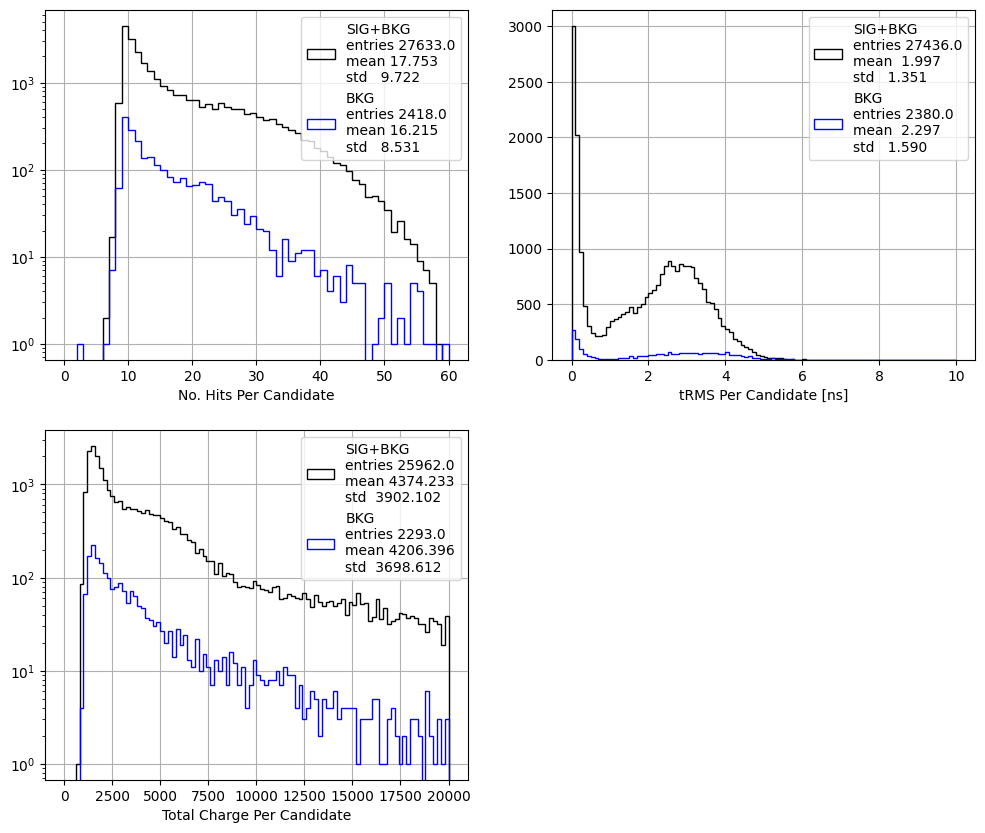

In [12]:
subplot = pltext.canvas(3)

subplot(1)
pltext.hist(df_sig.groupby("candidate_id").size(), 60, label="SIG+BKG", xylabels="No. Hits Per Candidate", ylog=True, range=(0, 60));
pltext.hist(df_bkg.groupby("candidate_id").size(), 60, label="BKG",     xylabels="No. Hits Per Candidate", ylog=True, range=(0, 60));

subplot(2)
pltext.hist(df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, 100, label="SIG+BKG", xylabels="tRMS Per Candidate [ns]", ylog=False, range=(0, 10));
pltext.hist(df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, 100, label="BKG"    , xylabels="tRMS Per Candidate [ns]", ylog=False, range=(0, 10));

subplot(3)
pltext.hist(df_sig.groupby("candidate_id")["hit_pmt_charges"].sum().values, 100, label="SIG+BKG", xylabels="Total Charge Per Candidate", ylog=True, range=(0, 20e3));
pltext.hist(df_bkg.groupby("candidate_id")["hit_pmt_charges"].sum().values, 100, label="BKG",     xylabels="Total Charge Per Candidate", ylog=True, range=(0, 20e3));

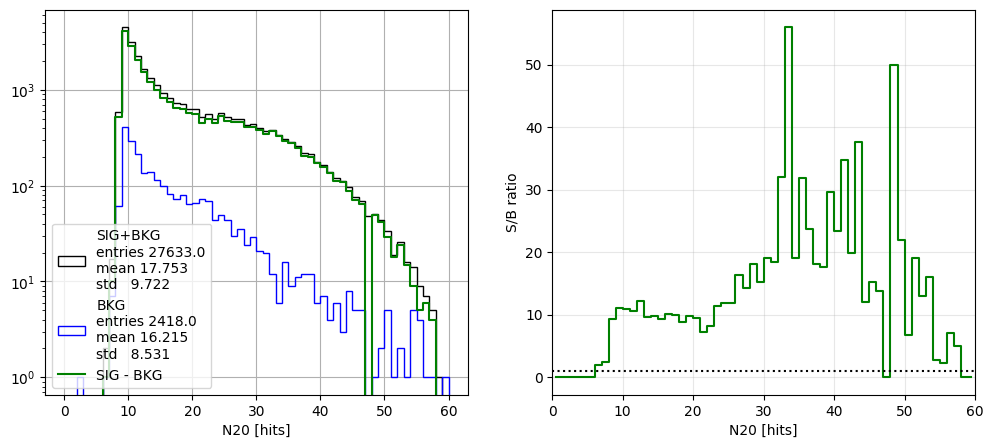

In [13]:
sup_thresh = 60

subplot = pltext.canvas(2)

subplot(1)
v_sig, b_sig, _ = pltext.hist(df_sig.groupby("candidate_id").size(), sup_thresh, label="SIG+BKG", xylabels="N20 [hits]", ylog=True, range=(0, sup_thresh));
v_bkg, b_bkg, _ = pltext.hist(df_bkg.groupby("candidate_id").size(), sup_thresh, label="BKG",     xylabels="N20 [hits]", ylog=True, range=(0, sup_thresh));

bin_centers = 0.5 * (b_sig[1:] + b_sig[:-1])
plt.step(bin_centers, np.subtract(v_sig, v_bkg, out=np.zeros_like(v_sig), where=v_bkg>0), where='mid', color='green', label="SIG - BKG");
plt.legend();

subplot(2)
bin_centers = 0.5 * (b_sig[1:] + b_sig[:-1])
ratio = np.divide(v_sig, v_bkg, out=np.zeros_like(v_sig), where=v_bkg>0)
plt.step(bin_centers, ratio, where='mid', color='green')
plt.ylabel("S/B ratio")
plt.xlabel("N20 [hits]")
plt.grid(alpha=0.3)
plt.xlim(0, sup_thresh)
plt.hlines(1.0, 0, sup_thresh, linestyles=":", color="k");

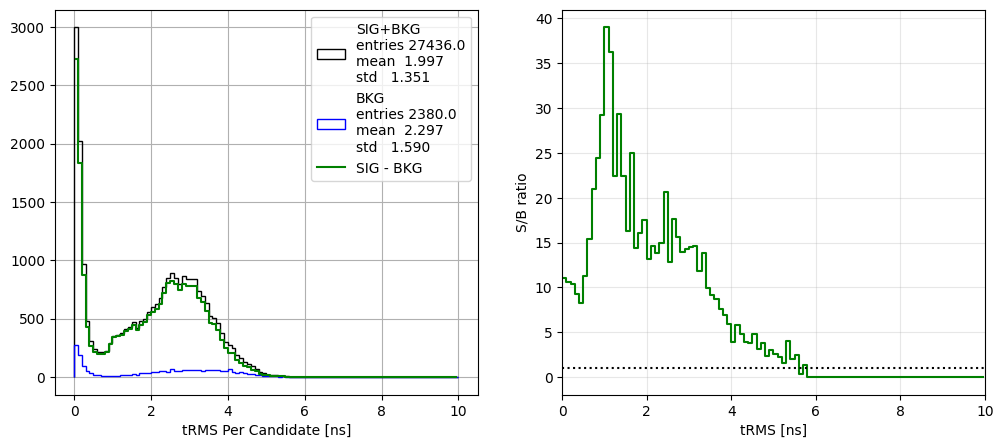

In [14]:
sup_thresh = 10 
subplot = pltext.canvas(2)

subplot(1)
v_sig, b_sig, _ = pltext.hist(df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, 100, label="SIG+BKG", xylabels="tRMS Per Candidate [ns]", ylog=False, range=(0, sup_thresh));
v_bkg, b_bkg, _ = pltext.hist(df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, 100, label="BKG"    , xylabels="tRMS Per Candidate [ns]", ylog=False, range=(0, sup_thresh));

bin_centers = 0.5 * (b_sig[1:] + b_sig[:-1])
plt.step(bin_centers, np.subtract(v_sig, v_bkg, out=np.zeros_like(v_sig), where=v_bkg>0), where='mid', color='green', label="SIG - BKG");
plt.legend();

subplot(2)
bin_centers = 0.5 * (b_sig[1:] + b_sig[:-1])
ratio = np.divide(v_sig, v_bkg, out=np.zeros_like(v_sig), where=v_bkg>0)
plt.step(bin_centers, ratio, where='mid', color='green')
plt.ylabel("S/B ratio")
plt.xlabel("tRMS [ns]")
plt.grid(alpha=0.3)
plt.xlim(0, sup_thresh)
plt.hlines(1.0, 0, sup_thresh, linestyles=":", color="k");

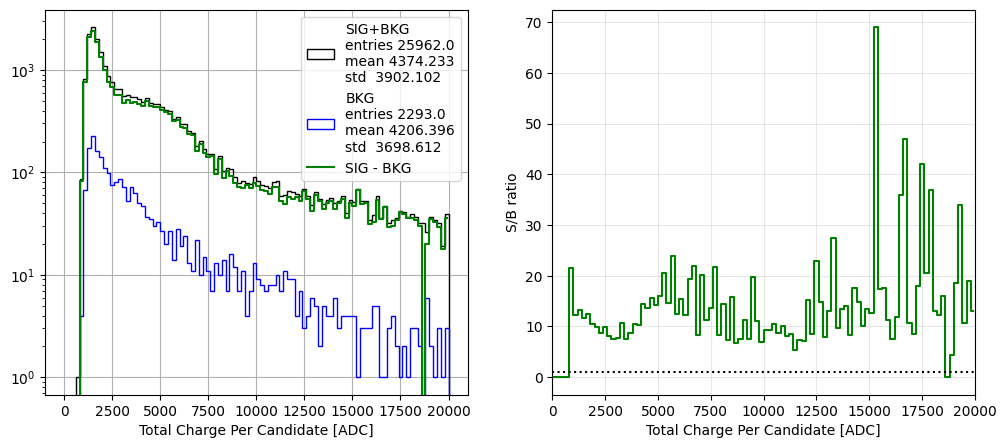

In [15]:
sup_thresh = 20e3 
subplot = pltext.canvas(2)

subplot(1)
v_sig, b_sig, _ = pltext.hist(df_sig.groupby("candidate_id")["hit_pmt_charges"].sum().values, 100, label="SIG+BKG", xylabels="Total Charge Per Candidate [ADC]", ylog=True, range=(0, sup_thresh));
v_bkg, b_bkg, _ = pltext.hist(df_bkg.groupby("candidate_id")["hit_pmt_charges"].sum().values, 100, label="BKG",     xylabels="Total Charge Per Candidate [ADC]", ylog=True, range=(0, sup_thresh));

bin_centers = 0.5 * (b_sig[1:] + b_sig[:-1])
plt.step(bin_centers, np.subtract(v_sig, v_bkg, out=np.zeros_like(v_sig), where=v_bkg>0), where='mid', color='green', label="SIG - BKG");
plt.legend();

subplot(2)
bin_centers = 0.5 * (b_sig[1:] + b_sig[:-1])
ratio = np.divide(v_sig, v_bkg, out=np.zeros_like(v_sig), where=v_bkg>0)
plt.step(bin_centers, ratio, where='mid', color='green')
plt.ylabel("S/B ratio")
plt.xlabel("Total Charge Per Candidate [ADC]")
plt.grid(alpha=0.3)
plt.xlim(0, sup_thresh)
plt.hlines(1.0, 0, sup_thresh, linestyles=":", color="k");

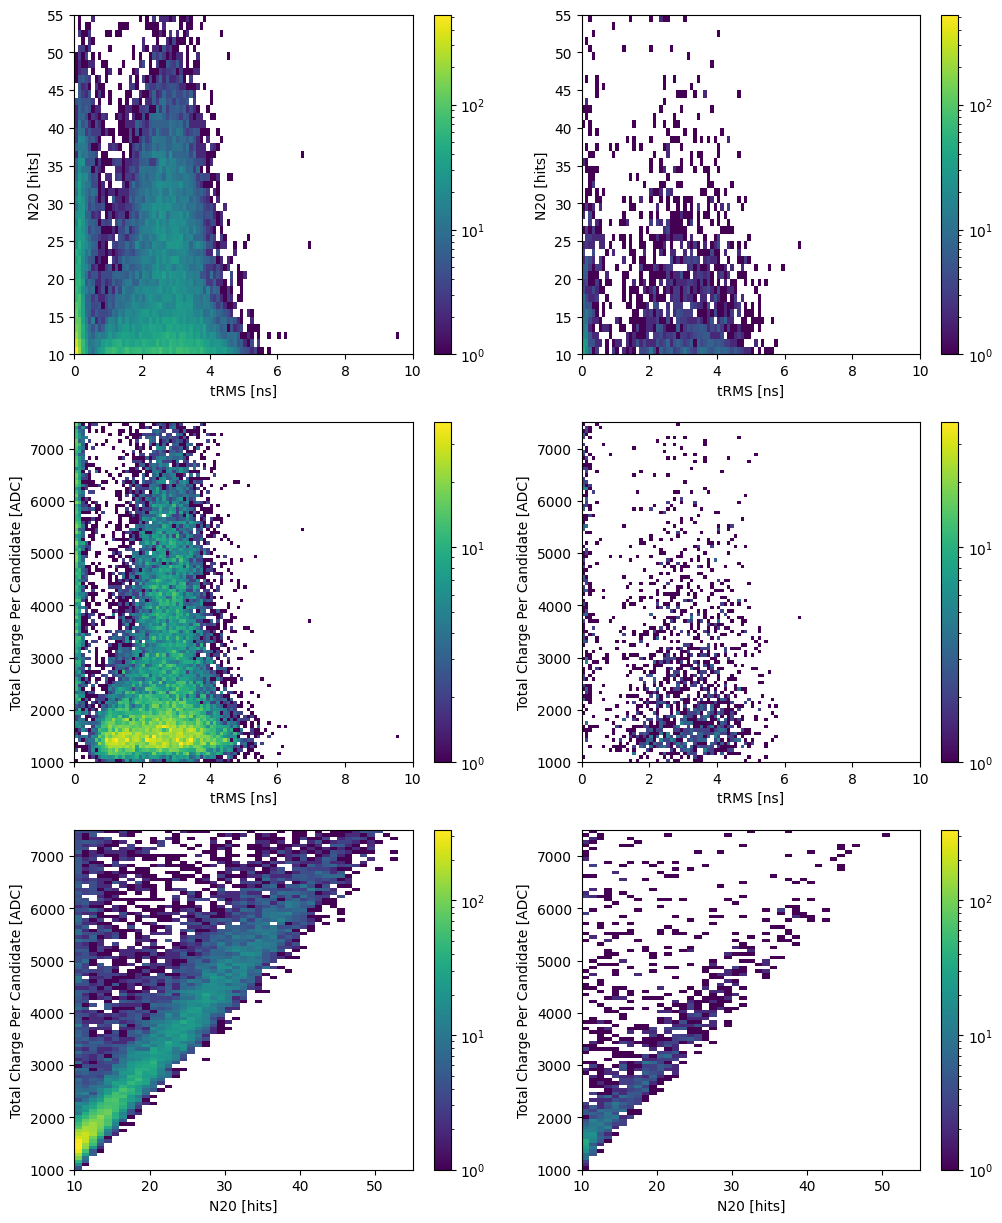

In [16]:
n20_inf = 10
n20_sup = 55
n20_bin = n20_sup-n20_inf
rms_inf = 0
rms_sup = 10
chr_inf = 1e3
chr_sup = 7.5e3

subplot = pltext.canvas(6)

subplot(1)
h1, xedges, yedges, im1 = plt.hist2d(df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, df_sig.groupby("candidate_id").size(), bins=(100, n20_bin), range=((rms_inf, rms_sup), (n20_inf, n20_sup)), norm="log")

plt.colorbar(im1)

plt.xlabel("tRMS [ns]");
plt.ylabel("N20 [hits]");

subplot(2)
h = plt.hist2d(df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, df_bkg.groupby("candidate_id").size(), bins=(100, n20_bin), range=((rms_inf, rms_sup), (n20_inf, n20_sup)), norm="log", vmax=h1.max())

plt.colorbar(h[3])

plt.xlabel("tRMS [ns]");
plt.ylabel("N20 [hits]");

subplot(3)
h1, xedges, yedges, im1 = plt.hist2d(df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, df_sig.groupby("candidate_id")["hit_pmt_charges"].sum().values, bins=(100, 100), range=((rms_inf, rms_sup), (chr_inf, chr_sup)), norm="log")

plt.colorbar(im1)

plt.xlabel("tRMS [ns]");
plt.ylabel("Total Charge Per Candidate [ADC]");

subplot(4)
h = plt.hist2d(df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, df_bkg.groupby("candidate_id")["hit_pmt_charges"].sum().values, bins=(100, 100), range=((rms_inf, rms_sup), (chr_inf, chr_sup)), norm="log", vmax=h1.max())

plt.colorbar(h[3])

plt.xlabel("tRMS [ns]");
plt.ylabel("Total Charge Per Candidate [ADC]");

subplot(5)
h1, xedges, yedges, im1 = plt.hist2d(df_sig.groupby("candidate_id").size(), df_sig.groupby("candidate_id")["hit_pmt_charges"].sum().values, bins=(n20_bin, 100), range=((n20_inf, n20_sup), (chr_inf, chr_sup)), norm="log")

plt.colorbar(im1)

plt.xlabel("N20 [hits]");
plt.ylabel("Total Charge Per Candidate [ADC]");

subplot(6)
h = plt.hist2d(df_bkg.groupby("candidate_id").size(), df_bkg.groupby("candidate_id")["hit_pmt_charges"].sum().values, bins=(n20_bin, 100), range=((n20_inf, n20_sup), (chr_inf, chr_sup)), norm="log", vmax=h1.max())

plt.colorbar(h[3])

plt.xlabel("N20 [hits]");
plt.ylabel("Total Charge Per Candidate [ADC]");

# Filter Data Using Cuts

In [17]:
event_vars_sig = (
    df_sig
    .groupby("candidate_id")
    .agg(
        n_hits    =("hit_pmt_calibrated_times", "size"),
        time_std  =("hit_pmt_calibrated_times", "std"),
        charge_sum=("hit_pmt_charges", "sum"),
    )
)

event_vars_bkg = (
    df_bkg
    .groupby("candidate_id")
    .agg(
        n_hits    =("hit_pmt_calibrated_times", "size"),
        time_std  =("hit_pmt_calibrated_times", "std"),
        charge_sum=("hit_pmt_charges", "sum"),
    )
)

In [18]:
cuts = (
    (event_vars_sig["n_hits"]     >= n20_inf)  & (event_vars_sig["n_hits"]     <= n20_sup) &
    (event_vars_sig["time_std"]   >= rms_inf ) & (event_vars_sig["time_std"]   <= rms_sup) &
    (event_vars_sig["charge_sum"] >= chr_inf)  & (event_vars_sig["charge_sum"] <= chr_sup)
)
cuts_bkg = (
    (event_vars_bkg["n_hits"]     >= n20_inf) & (event_vars_bkg["n_hits"]     <= n20_sup) &
    (event_vars_bkg["time_std"]   >= rms_inf) & (event_vars_bkg["time_std"]   <= rms_sup) &
    (event_vars_bkg["charge_sum"] >= chr_inf) & (event_vars_bkg["charge_sum"] <= chr_sup)
)

In [19]:
good_candidates_sig = event_vars_sig.index[cuts]
good_candidates_bkg = event_vars_bkg.index[cuts_bkg]

In [20]:
df_sig_cut = df_sig[df_sig["candidate_id"].isin(good_candidates_sig)]
df_bkg_cut = df_bkg[df_bkg["candidate_id"].isin(good_candidates_bkg)]

In [21]:
print(f"SIG+BKG: {len(df_sig['event_id'].unique())} → {len(df_sig_cut['event_id'].unique())}: {len(df_sig_cut['event_id'].unique())/len(df_sig['event_id'].unique())*100:.0f}% reduction after cuts.")
print(f"BKG:     {len(df_bkg['event_id'].unique())} → {len(df_bkg_cut['event_id'].unique())}: {len(df_bkg_cut['event_id'].unique())/len(df_bkg['event_id'].unique())*100:.0f}% reduction after cuts.")

SIG+BKG: 9824 → 8116: 83% reduction after cuts.
BKG:     1524 → 1046: 69% reduction after cuts.


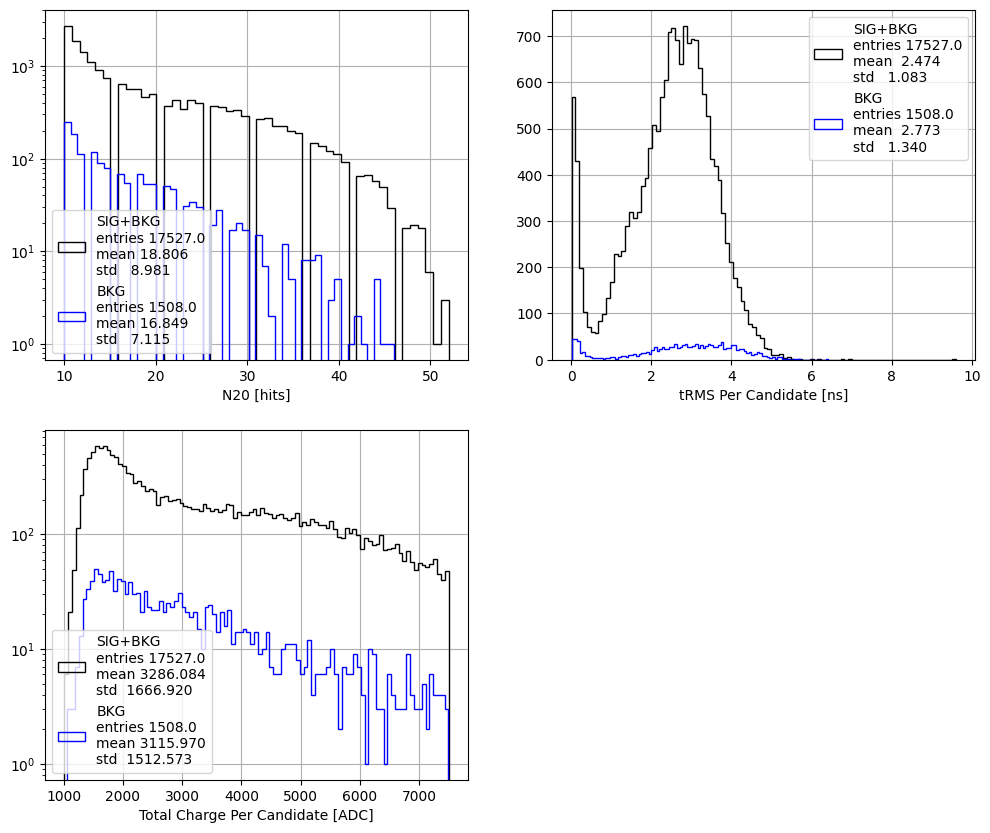

In [23]:
subplot = pltext.canvas(3)

subplot(1)
pltext.hist(df_sig_cut.groupby("candidate_id").size(), 50, xylabels="N20 [hits]", label="SIG+BKG", ylog=True);
pltext.hist(df_bkg_cut.groupby("candidate_id").size(), 50, xylabels="N20 [hits]", label="BKG",     ylog=True);

subplot(2)
pltext.hist(df_sig_cut.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, 100, xylabels="tRMS Per Candidate [ns]", label="SIG+BKG");
pltext.hist(df_bkg_cut.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values, 100, xylabels="tRMS Per Candidate [ns]", label="BKG");

subplot(3)
pltext.hist(df_sig_cut.groupby("candidate_id")["hit_pmt_charges"].sum().values, 100, xylabels="Total Charge Per Candidate [ADC]", label="SIG+BKG", ylog=True);
pltext.hist(df_bkg_cut.groupby("candidate_id")["hit_pmt_charges"].sum().values, 100, xylabels="Total Charge Per Candidate [ADC]", label="BKG",     ylog=True);

# Create Pure Signal Sample

In [24]:
pmts_bkg = df_bkg_cut["pmt_id"]
pmts_sig = df_sig_cut["pmt_id"]

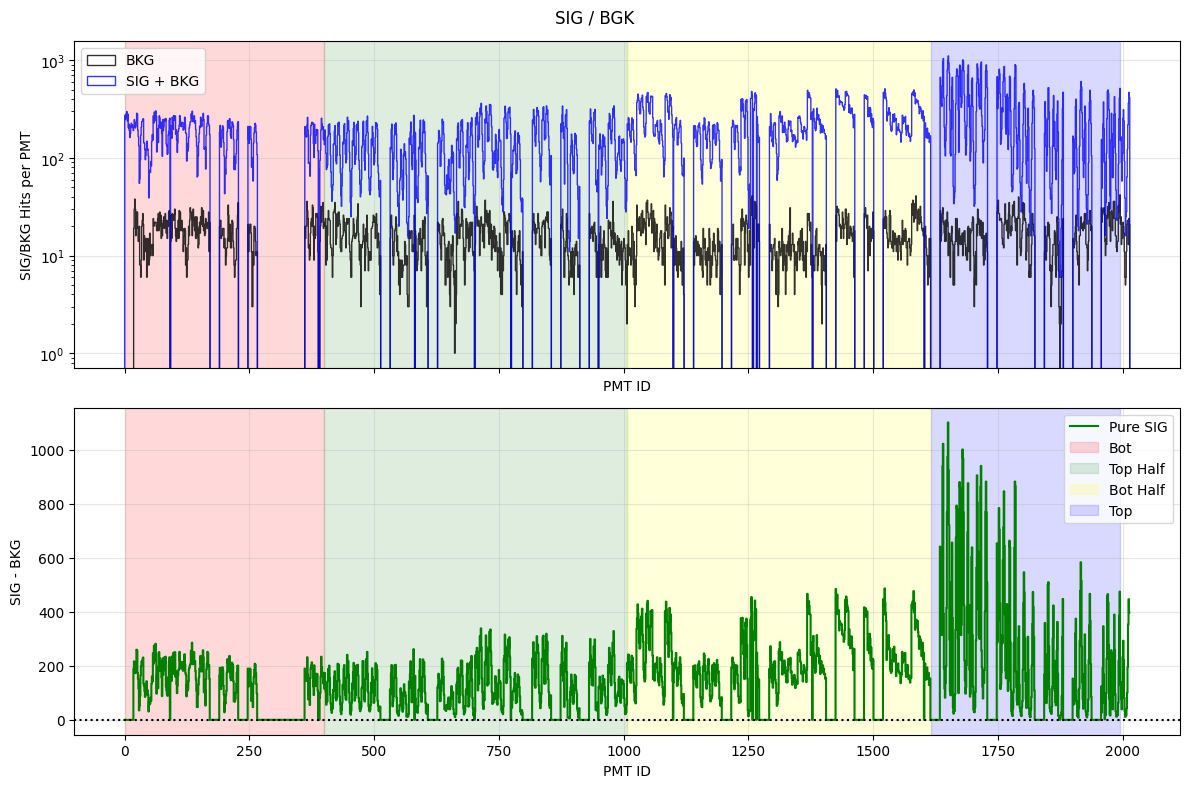

In [25]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2,2]}
)

# --- DigiHits por PMT ---
ax1.hist(pmts_bkg, 2014, range=(0, 2014), histtype="step", alpha=0.8, label="BKG");
ax1.hist(pmts_sig, 2014, range=(0, 2014), histtype="step", alpha=0.8, label="SIG + BKG");

ax1.set_yscale("log")
ax1.set_ylabel("SIG/BKG Hits per PMT")
ax1.set_xlabel("PMT ID")
ax1.legend()
ax1.grid(alpha=0.3)

# # --- Regiones del detector ---
ax1.axvspan(0, 21*19,      color="red", alpha=0.15)
ax1.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax1.axvspan(53*19, 85*19,  color="yellow", alpha=0.15)
ax1.axvspan(85*19, 105*19, color="blue", alpha=0.15)

# --- Ratio ---
bkg_hits_per_pmt = np.bincount(
    pmts_bkg.astype(int),
    minlength=2014
)

sig_hits_per_pmt = np.bincount(
    pmts_sig.astype(int),
    minlength=2014
)

mask = bkg_hits_per_pmt > 0
pure_signal = np.zeros(2014)
pure_signal[mask] = sig_hits_per_pmt[mask] - bkg_hits_per_pmt[mask]

ax2.step(range(2014), pure_signal, where="mid", color="green", label="Pure SIG")
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("SIG - BKG")
ax2.set_xlabel("PMT ID")
# ax2.set_yscale("log")
ax2.grid(alpha=0.3)
plt.legend();

# # --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red",         alpha=0.15, label="Bot")
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15, label="Top Half")
ax2.axvspan(53*19, 85*19,  color="yellow",      alpha=0.15, label="Bot Half")
ax2.axvspan(85*19, 105*19, color="blue",        alpha=0.15, label="Top")
ax2.legend()

plt.suptitle("SIG / BGK", y=0.98)
plt.tight_layout()

In [26]:
ps = df_sig_cut.groupby("pmt_id")["hit_pmt_charges"].sum().index.to_numpy(dtype=int)
cs = df_sig_cut.groupby("pmt_id")["hit_pmt_charges"].sum().to_numpy()
css = np.zeros(2014)
css[ps] = cs

pb = df_bkg_cut.groupby("pmt_id")["hit_pmt_charges"].sum().index.to_numpy(dtype=int)
cb = df_bkg_cut.groupby("pmt_id")["hit_pmt_charges"].sum().to_numpy()
cbb = np.zeros(2014)
cbb[pb] = cb

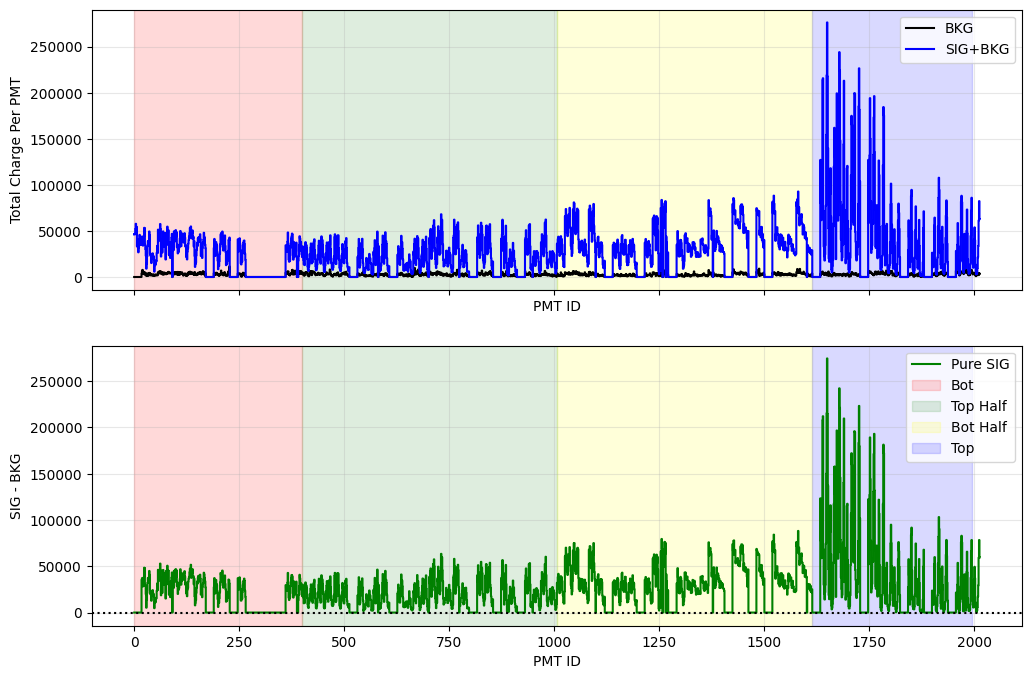

In [27]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2,2]}
)

ax1.step(range(2014), cbb,  where="mid", label="BKG");
ax1.step(range(2014), css,  where="mid", label="SIG+BKG");
ax1.set_xlabel("PMT ID");
ax1.set_ylabel("Total Charge Per PMT");
ax1.grid(alpha=0.3)
ax1.axvspan(0, 21*19,      color="red",         alpha=0.15)
ax1.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax1.axvspan(53*19, 85*19,  color="yellow",      alpha=0.15)
ax1.axvspan(85*19, 105*19, color="blue",        alpha=0.15)
ax1.legend();

mask = cbb > 0
pure_charge = np.zeros(2014)
pure_charge[mask] = css[mask] - cbb[mask]
ax2.step(range(2014), pure_charge, where="mid", color="green", label="Pure SIG");
ax2.set_xlabel("PMT ID");
ax2.set_ylabel("SIG - BKG");
ax2.axhline(1.0, linestyle=":", color="k")
ax2.grid(alpha=0.3)

ax2.axvspan(0, 21*19,      color="red",         alpha=0.15, label="Bot")
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15, label="Top Half")
ax2.axvspan(53*19, 85*19,  color="yellow",      alpha=0.15, label="Bot Half")
ax2.axvspan(85*19, 105*19, color="blue",        alpha=0.15, label="Top")
ax2.legend();

# Read MC Data

In [28]:
from WCSimFilePackages.npz_to_df import simple_truehits_info_to_df, digihits_info_to_df

npz_down = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1767_CDSON_15kevents.npz'
nevents  = 15000

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_down = simple_truehits_info_to_df(npz_down).dropna()
df_digiHits_down = digihits_info_to_df(npz_down, nevents).dropna()

In [29]:
from WCTE_event_display.EventDisplay      import EventDisplay

#1) make an instance of the event display class
eventDisplay = EventDisplay() 

#2) start by loading in the CSV file for how the mPMTs are mapped to 2d event display
#unwraps based on the mPMT slot ID 
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')

#mask out mPMT slots - newer WCSim doesn't have these mPMTs loaded  
#WCTE slot numbering
# eventDisplay.mask_mPMTs([45,77,79,27,32,85,91,99,12,14,16,18])
#WCSim container numbering
# eventDisplay.mask_mPMTs([20,73,38,49,55,65,67,33,71,92,101,95])

#3) load the WCSim mapping tube no to slot number
#for WCSim using the numpy output we need the mapping between the tube_number in WCSim and the slot and mPMT number in the detector
#this can be obtained from the geofile that WCSim produces 
#This changes if the CDS is implemented or not
eventDisplay.load_wcsim_tubeno_mapping("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt")

In [30]:
import json

# Cargar los datos de gaps del análisis anterior
with open('/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim_old/install/npz/gap_analysis_data.json', 'r') as f:
    gap_data = json.load(f)
    
invalid_pmt_id = []
for i in range(len(gap_data["gaps_detalle"])):
    invalid_pmt_id.append(gap_data["gaps_detalle"][i]["numeros_faltantes"])

invalid_pmt_id = np.concatenate(invalid_pmt_id)

In [38]:
no_candidates_sig = df_sig_cut.candidate_id.nunique() - df_bkg_cut.candidate_id.nunique()
no_candidates_mc  = df_digiHits_down.event_id.nunique()

print(no_candidates_mc, no_candidates_sig)

14935 16019


In [39]:
mc = df_digiHits_down
tube_no = mc["digi_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
mc_pmt_id = mPMT_id_1771 * 19 + PMT_pos_1771

df_digiHits_down["pmt_id"] = mc_pmt_id

mc_pmt_id = np.array(
    [pmt for pmt in mc_pmt_id if pmt not in invalid_pmt_id]
)

print(len(mc["event_id"].unique()))

[40 40 40 ... 53 51 51]
14935


In [40]:
ps = df_digiHits_down.groupby("pmt_id")["digi_hit_charge"].sum().index.to_numpy(dtype=int)
cs = df_digiHits_down.groupby("pmt_id")["digi_hit_charge"].sum().to_numpy()
count = df_digiHits_down.groupby("pmt_id")["digi_hit_charge"].count().to_numpy()
mcss = np.zeros(2014)
mcss[ps] = cs
countmc = np.zeros(2014)
countmc[ps] = count

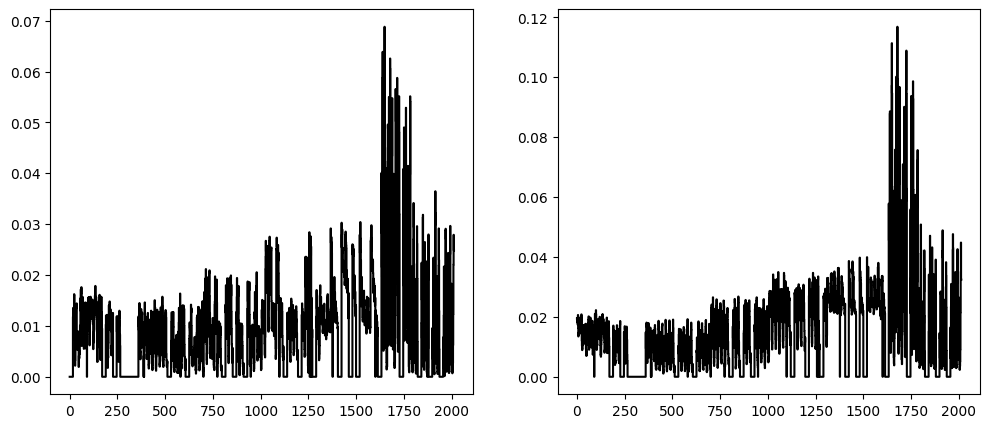

In [41]:
subplot = pltext.canvas(2)

subplot(1)
plt.step(range(2014), pure_signal/no_candidates_sig);

subplot(2)
mc_signal = np.bincount(mc_pmt_id, minlength=2014)

plt.step(range(2014), mc_signal/no_candidates_mc);

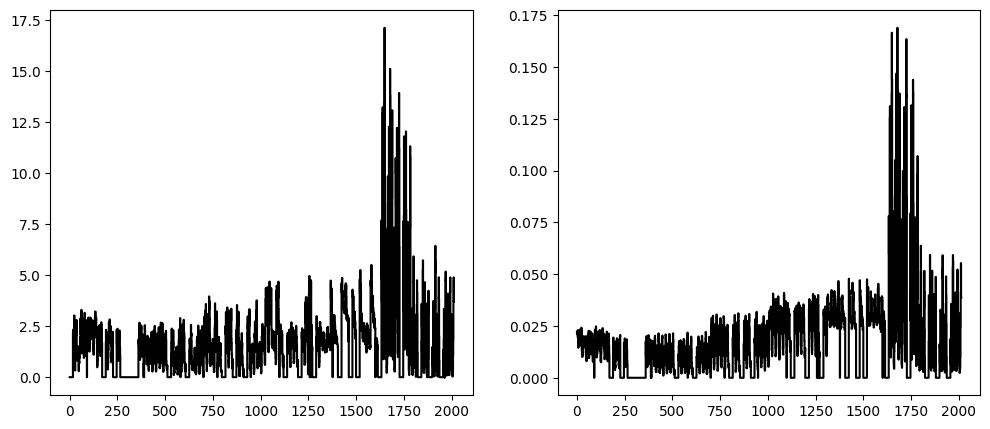

In [42]:
subplot = pltext.canvas(2)

subplot(1)
plt.step(range(2014), pure_charge/no_candidates_sig);

subplot(2)
mcss[invalid_pmt_id] = 0.0
plt.step(range(2014), mcss/no_candidates_mc);

# Compare Data VS. MC

#### RQE

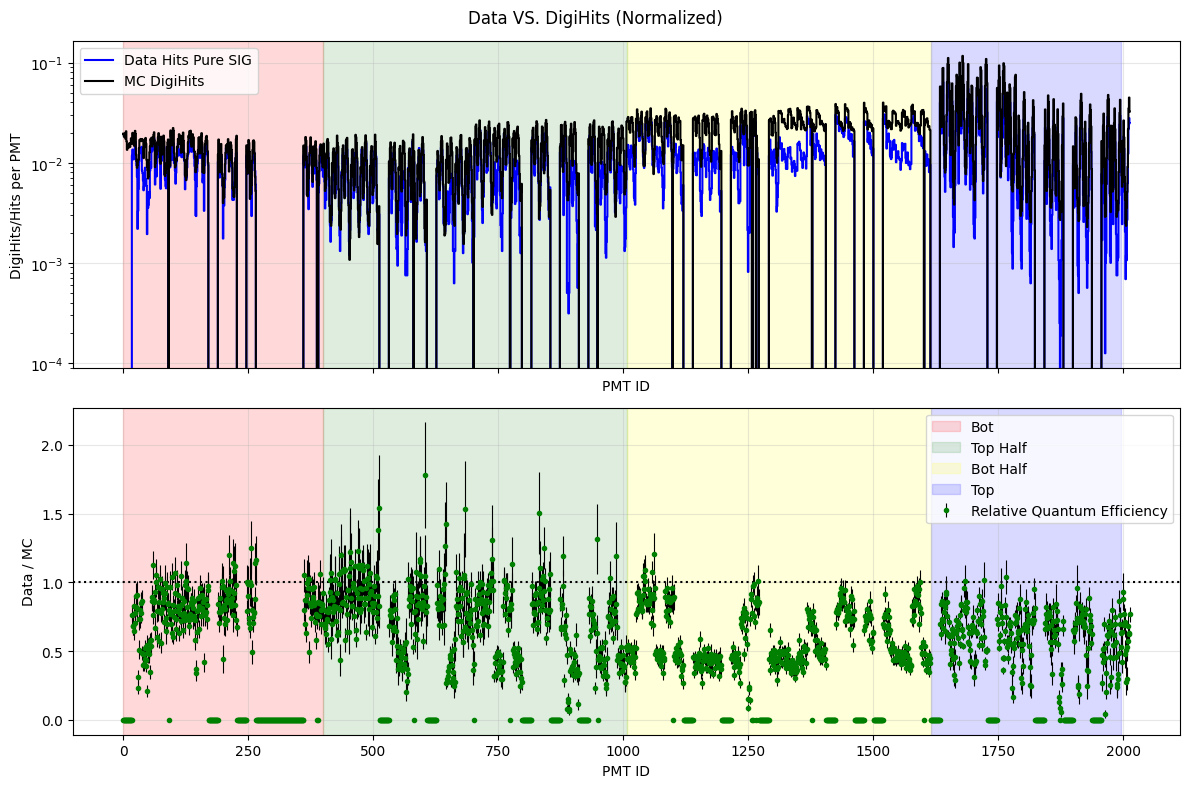

In [43]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2,2]}
)

# --- DigiHits por PMT ---
ax1.step(range(2014), pure_signal/no_candidates_sig,    where="mid", color="blue",  label="Data Hits Pure SIG")
ax1.step(range(2014), mc_signal/no_candidates_mc, where="mid", color="black", label="MC DigiHits")

ax1.set_yscale("log")
ax1.set_ylabel("DigiHits/Hits per PMT")
ax1.set_xlabel("PMT ID")
ax1.axvspan(0, 21*19,      color="red",         alpha=0.15)
ax1.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax1.axvspan(53*19, 85*19,  color="yellow",      alpha=0.15)
ax1.axvspan(85*19, 105*19, color="blue",        alpha=0.15)
ax1.legend()
ax1.grid(alpha=0.3)

# --- Hits por PMT normalizados ---
N_data = pure_signal          # conteos por PMT
N_mc   = mc_signal            # conteos por PMT

data_hits_per_pmt = N_data / no_candidates_sig
mc_hits_per_pmt   = N_mc   / no_candidates_mc

# --- Errores Poissonianos por bin ---
error_data = np.zeros(2014)
error_mc   = np.zeros(2014)

mask_data = N_data > 0
mask_mc   = N_mc   > 0

error_data[mask_data] = np.sqrt(N_data[mask_data]) / no_candidates_sig
error_mc[mask_mc]     = np.sqrt(N_mc[mask_mc])   / no_candidates_mc

# --- Ratio Data / MC y su error ---
relative_qe       = np.zeros(2014)
error_relative_qe = np.zeros(2014)

mask = (mc_hits_per_pmt > 0) & (data_hits_per_pmt > 0)

relative_qe[mask] = data_hits_per_pmt[mask] / mc_hits_per_pmt[mask]

error_relative_qe[mask] = np.sqrt(
    (error_data[mask] / mc_hits_per_pmt[mask])**2
    +
    (data_hits_per_pmt[mask] * error_mc[mask] / mc_hits_per_pmt[mask]**2)**2
)

ax2.errorbar(
    range(2014),
    relative_qe,
    yerr=error_relative_qe,
    fmt="o",
    markersize=3,
    markerfacecolor="green",
    markeredgecolor="green",
    ecolor="black",        # color de las barras de error
    elinewidth=0.8,
    capsize=0,
    label="Relative Quantum Efficiency"
)
# ax2.scatter(range(2014), relative_qe, color="green", s=2, label="Relative Quantum Efficiency", zorder=2)
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT ID")
ax2.grid(alpha=0.3)
# ax2.set_ylim(-2, 4)
plt.legend()

# --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red",         alpha=0.15, label="Bot")
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15, label="Top Half")
ax2.axvspan(53*19, 85*19,  color="yellow",      alpha=0.15, label="Bot Half")
ax2.axvspan(85*19, 105*19, color="blue",        alpha=0.15, label="Top")
ax2.legend()

plt.suptitle("Data VS. DigiHits (Normalized)", y=0.98)
plt.tight_layout()

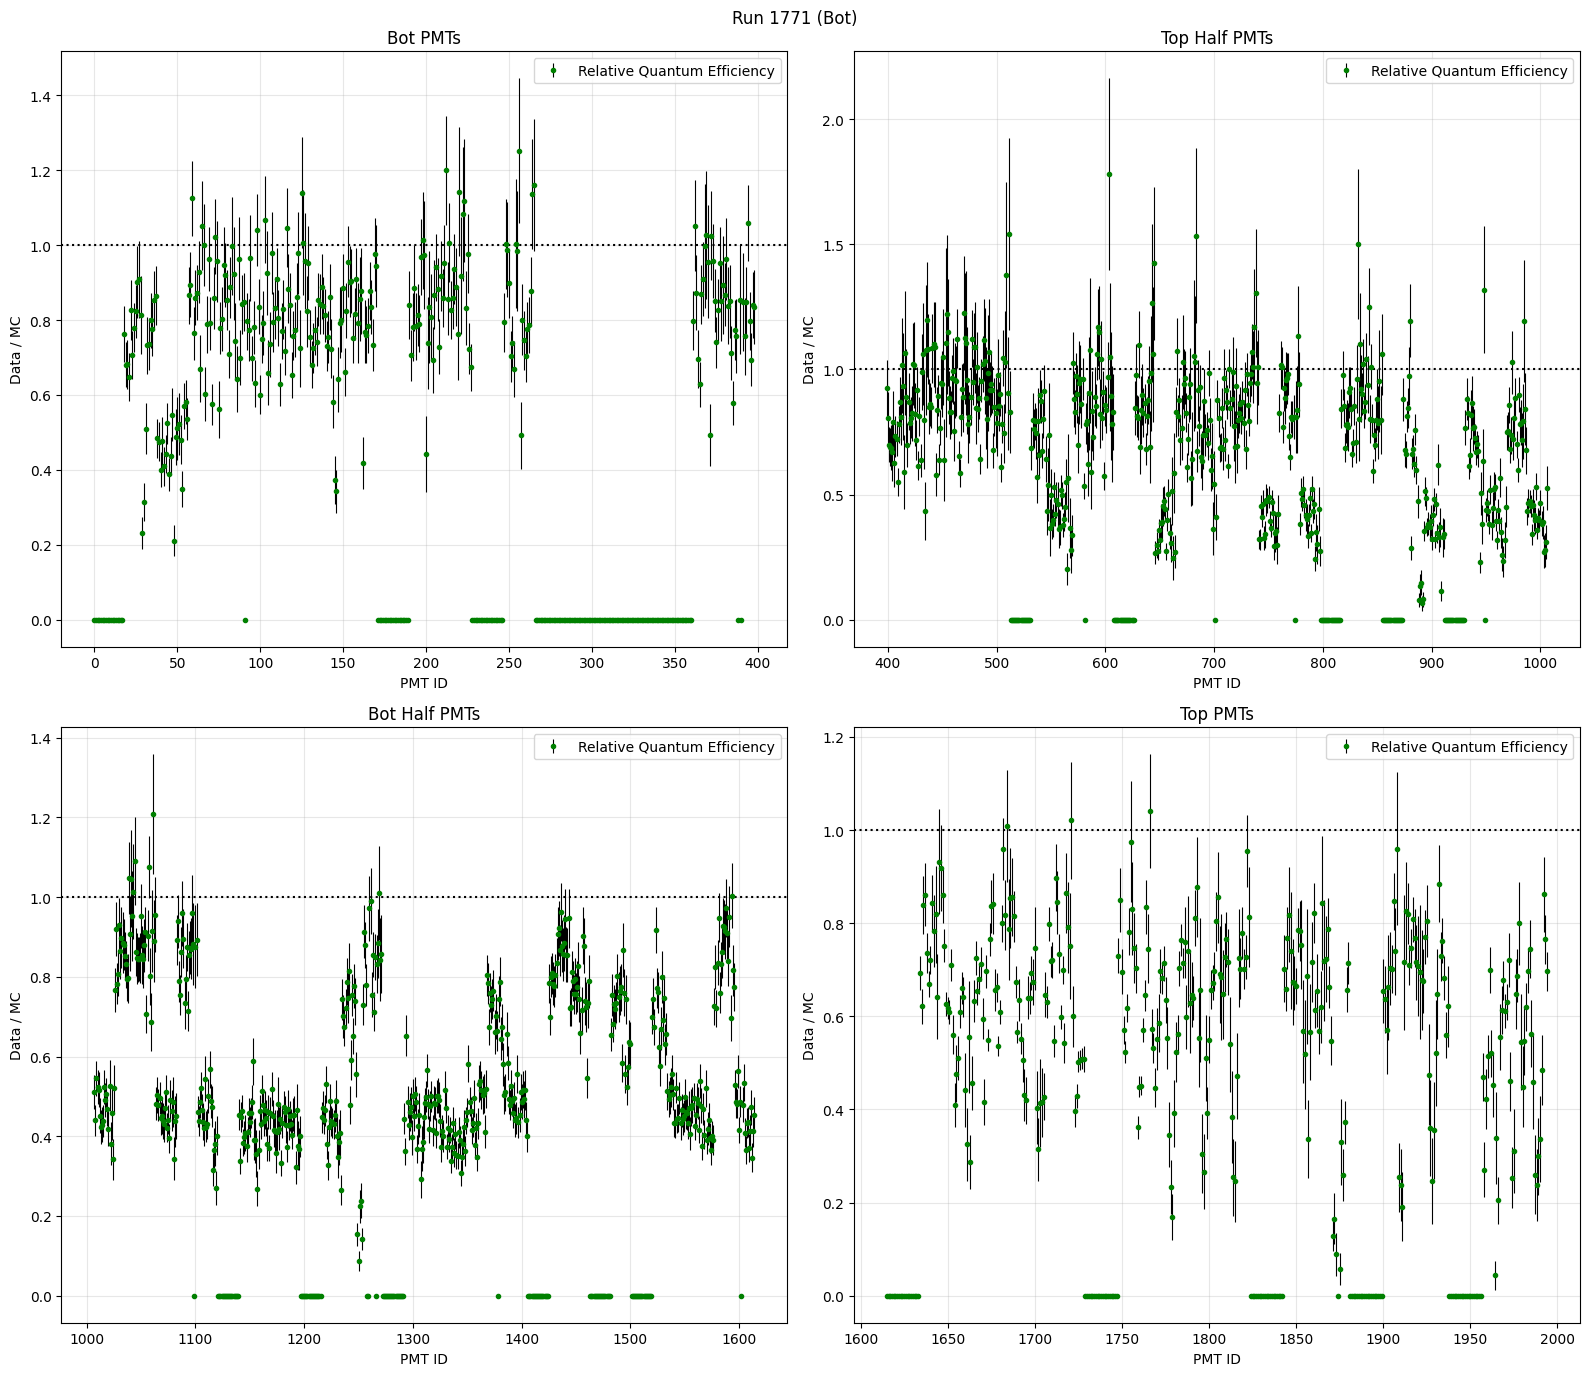

In [44]:
# --- Hits por PMT normalizados ---
N_data = pure_signal          # conteos por PMT
N_mc   = mc_signal            # conteos por PMT

data_hits_per_pmt = N_data / no_candidates_sig
mc_hits_per_pmt   = N_mc   / no_candidates_mc

# --- Errores Poissonianos por bin ---
error_data = np.zeros(2014)
error_mc   = np.zeros(2014)

mask_data = N_data > 0
mask_mc   = N_mc   > 0

error_data[mask_data] = np.sqrt(N_data[mask_data]) / no_candidates_sig
error_mc[mask_mc]     = np.sqrt(N_mc[mask_mc])   / no_candidates_mc

# --- Ratio Data / MC y su error ---
relative_qe       = np.zeros(2014)
error_relative_qe = np.zeros(2014)

mask = (mc_hits_per_pmt > 0) & (data_hits_per_pmt > 0)

relative_qe[mask] = data_hits_per_pmt[mask] / mc_hits_per_pmt[mask]

error_relative_qe[mask] = np.sqrt(
    (error_data[mask] / mc_hits_per_pmt[mask])**2
    +
    (data_hits_per_pmt[mask] * error_mc[mask] / mc_hits_per_pmt[mask]**2)**2
)

subplot = pltext.canvas(4, 2, 7, 8)

subplot(1)
plt.errorbar(
    range(21*19),
    relative_qe[:21*19],
    yerr=error_relative_qe[:21*19],
    fmt="o",
    markersize=3,
    markerfacecolor="green",
    markeredgecolor="green",
    ecolor="black",        # color de las barras de error
    elinewidth=0.8,
    capsize=0,
    label="Relative Quantum Efficiency"
);
plt.title("Bot PMTs")
plt.axhline(1.0, linestyle=":", color="k")
plt.ylabel("Data / MC")
plt.xlabel("PMT ID")
plt.grid(alpha=0.3)
plt.legend(loc="upper right");

subplot(2)
plt.errorbar(
    range(21*19, 53*19),
    relative_qe[21*19:53*19],
    yerr=error_relative_qe[21*19:53*19],
    fmt="o",
    markersize=3,
    markerfacecolor="green",
    markeredgecolor="green",
    ecolor="black",        # color de las barras de error
    elinewidth=0.8,
    capsize=0,
    label="Relative Quantum Efficiency"
);
plt.title("Top Half PMTs")
plt.axhline(1.0, linestyle=":", color="k")
plt.ylabel("Data / MC")
plt.xlabel("PMT ID")
plt.grid(alpha=0.3)
plt.legend(loc="upper right");

subplot(3)
plt.errorbar(
    range(53*19, 85*19),
    relative_qe[53*19:85*19],
    yerr=error_relative_qe[53*19:85*19],
    fmt="o",
    markersize=3,
    markerfacecolor="green",
    markeredgecolor="green",
    ecolor="black",        # color de las barras de error
    elinewidth=0.8,
    capsize=0,
    label="Relative Quantum Efficiency"
);
plt.title("Bot Half PMTs")
plt.axhline(1.0, linestyle=":", color="k")
plt.ylabel("Data / MC")
plt.xlabel("PMT ID")
plt.grid(alpha=0.3)
plt.legend(loc="upper right");

subplot(4)
plt.errorbar(
    range(85*19, 105*19),
    relative_qe[85*19:105*19],
    yerr=error_relative_qe[85*19:105*19],
    fmt="o",
    markersize=3,
    markerfacecolor="green",
    markeredgecolor="green",
    ecolor="black",        # color de las barras de error
    elinewidth=0.8,
    capsize=0,
    label="Relative Quantum Efficiency"
);
plt.title("Top PMTs");
plt.axhline(1.0, linestyle=":", color="k")
plt.ylabel("Data / MC")
plt.xlabel("PMT ID")
plt.grid(alpha=0.3)
plt.legend(loc="upper right");

plt.suptitle("Run 1771 (Bot)", y=0.98);
plt.tight_layout();

In [ ]:
# np.savez("data_files/test_pure_signal_1771.npz",      pure_signal);
# np.savez("data_files/test_mc_signal_1771.npz",        mc_signal);
# np.savez("data_files/test_sig_noCandidates_1771.npz", no_candidates_sig);
# np.savez("data_files/test_mc_noCandidates_1771.npz",  no_candidates_mc);

#### Charge

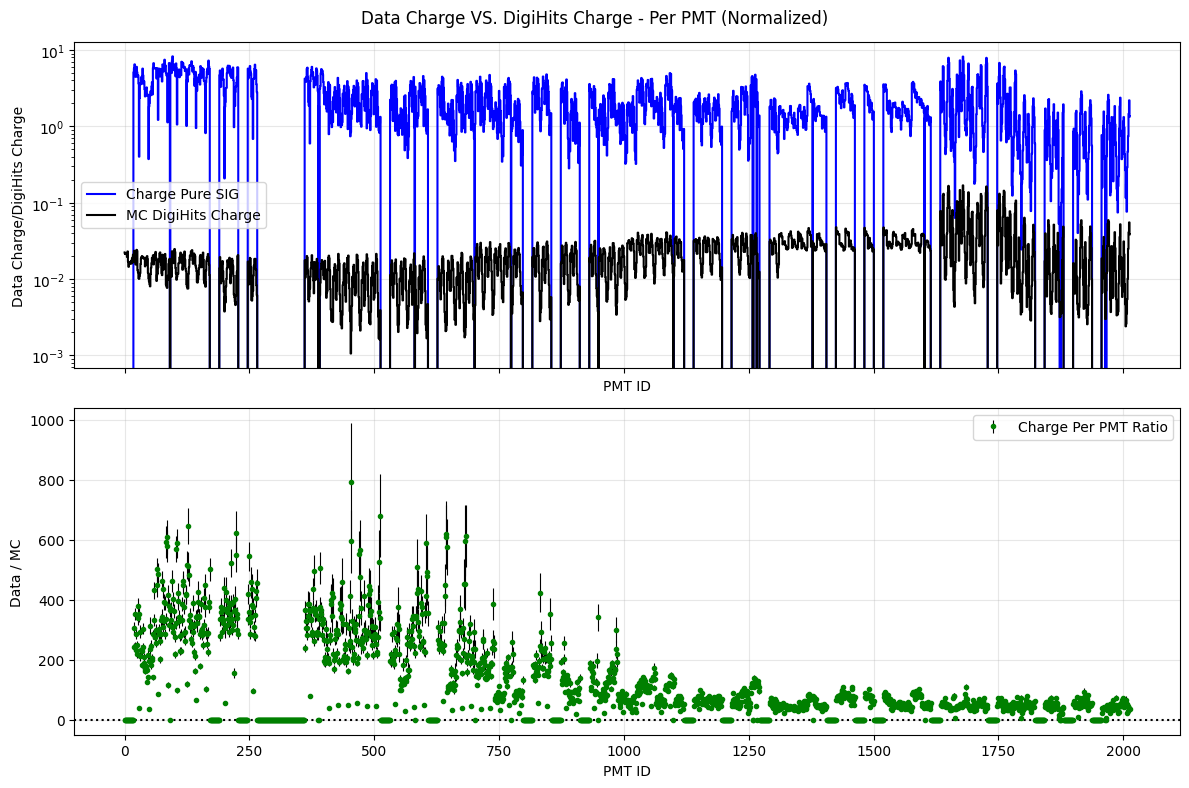

In [32]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2,2]}
)

# --- DigiHits por PMT ---
ax1.step(range(2014), pure_charge/no_candidates_sig,    where="mid", color="blue",  label="Charge Pure SIG")
ax1.step(range(2014), mcss/no_candidates_mc,            where="mid", color="black", label="MC DigiHits Charge")

ax1.set_yscale("log")
ax1.set_ylabel("Data Charge/DigiHits Charge")
ax1.set_xlabel("PMT ID")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Hits por PMT normalizados ---
N_data = pure_charge          # conteos por PMT
N_mc   = mcss            # conteos por PMT

data_hits_per_pmt = N_data / no_candidates_sig
mc_hits_per_pmt   = N_mc   / no_candidates_mc

# --- Errores Poissonianos por bin ---
error_data = np.zeros(2014)
error_mc   = np.zeros(2014)

mask_data = N_data > 0
mask_mc   = N_mc   > 0

error_data[mask_data] = np.sqrt(N_data[mask_data]) / no_candidates_sig
error_mc[mask_mc]     = np.sqrt(N_mc[mask_mc])   / no_candidates_mc

# --- Ratio Data / MC y su error ---
relative_qe       = np.zeros(2014)
error_relative_qe = np.zeros(2014)

mask = (mc_hits_per_pmt > 0) & (data_hits_per_pmt > 0)

relative_qe[mask] = data_hits_per_pmt[mask] / mc_hits_per_pmt[mask]

error_relative_qe[mask] = np.sqrt(
    (error_data[mask] / mc_hits_per_pmt[mask])**2
    +
    (data_hits_per_pmt[mask] * error_mc[mask] / mc_hits_per_pmt[mask]**2)**2
)

ax2.errorbar(
    range(2014),
    relative_qe,
    yerr=error_relative_qe,
    fmt="o",
    markersize=3,
    markerfacecolor="green",
    markeredgecolor="green",
    ecolor="black",        # color de las barras de error
    elinewidth=0.8,
    capsize=0,
    label="Charge Per PMT Ratio"
)
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT ID")
ax2.grid(alpha=0.3)
# ax2.set_ylim(-2, 4)
plt.legend()

plt.suptitle("Data Charge VS. DigiHits Charge - Per PMT (Normalized)", y=0.98)
plt.tight_layout()

# Event Display

In [33]:
from WCTE_event_display.EventDisplay import EventDisplay
import matplotlib.colors as colors

#1) make an instance of the event display class
eventDisplay = EventDisplay() 

#2) start by loading in the CSV file for how the mPMTs are mapped to 2d event display
#unwraps based on the mPMT slot ID 
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')

#mask out mPMT slots - newer WCSim doesn't have these mPMTs loaded  
#WCTE slot numbering
# eventDisplay.mask_mPMTs([45,77,79,27,32,85,91,99,12,14,16,18])
#WCSim container numbering
# eventDisplay.mask_mPMTs([20,73,38,49,55,65,67,33,71,92,101,95])

#3) load the WCSim mapping tube no to slot number
#for WCSim using the numpy output we need the mapping between the tube_number in WCSim and the slot and mPMT number in the detector
#this can be obtained from the geofile that WCSim produces 
#This changes if the CDS is implemented or not
eventDisplay.load_wcsim_tubeno_mapping("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt")

(2014,)
(2014,)
(2014,)
[40 40 40 ... 53 51 51]
(2014,)


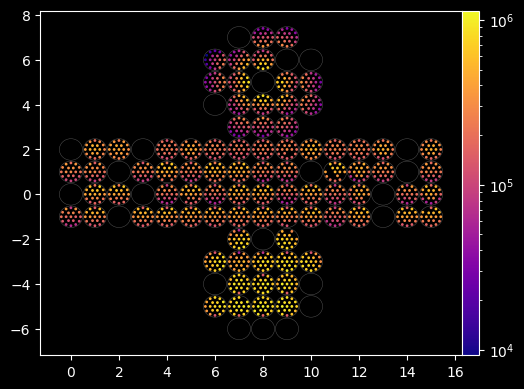

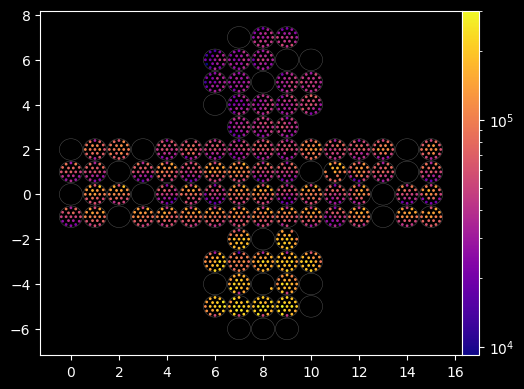

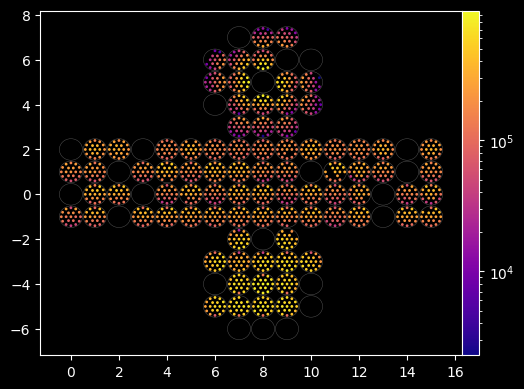

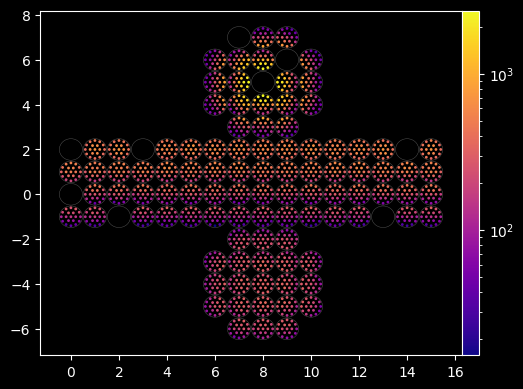

In [34]:
######## SIG + BKG CUTS ############
data_to_plot = df_sig_cut["hit_pmt_charges"]

#map from the tube number to the mPMT slot and position number
data_to_plot = eventDisplay.process_data(df_sig_cut["hit_mpmt_slot_ids"].to_numpy(dtype=int), df_sig_cut["hit_pmt_position_ids"].to_numpy(dtype=int), data_to_plot)
eventDisplay.plotEventDisplay(data_to_plot,color_norm=colors.LogNorm(), style= "dark_background")

plt.style.use('default');
pltext.style()

######## BKG CUTS ############
data_to_plot = df_bkg_cut["hit_pmt_charges"]

#map from the tube number to the mPMT slot and position number
data_to_plot = eventDisplay.process_data(df_bkg_cut["hit_mpmt_slot_ids"].to_numpy(dtype=int), df_bkg_cut["hit_pmt_position_ids"].to_numpy(dtype=int), data_to_plot)
eventDisplay.plotEventDisplay(data_to_plot,color_norm=colors.LogNorm(), style= "dark_background")

plt.style.use('default');
pltext.style()

######## PURE SIGNAL ############
data_to_plot_sig = eventDisplay.process_data(df_sig_cut["hit_mpmt_slot_ids"].to_numpy(dtype=int), df_sig_cut["hit_pmt_position_ids"].to_numpy(dtype=int), df_sig_cut["hit_pmt_charges"])
data_to_plot_bkg = eventDisplay.process_data(df_bkg_cut["hit_mpmt_slot_ids"].to_numpy(dtype=int), df_bkg_cut["hit_pmt_position_ids"].to_numpy(dtype=int), df_bkg_cut["hit_pmt_charges"])
eventDisplay.plotEventDisplay(data_to_plot_sig - data_to_plot_bkg, color_norm=colors.LogNorm(), style= "dark_background")

plt.style.use('default');
pltext.style()

######## WCSIM ############
data = df_digiHits_down
tube_no = data["digi_hit_pmt"] + 1
data_to_plot = data["digi_hit_charge"]

#map from the tube number to the mPMT slot and position number
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
data_to_plot = eventDisplay.process_data(mPMT_id_1771, PMT_pos_1771, data_to_plot)
eventDisplay.plotEventDisplay(data_to_plot,color_norm=colors.LogNorm(), style= "dark_background")

plt.style.use('default');
pltext.style()

In [35]:
ps = df_sig_cut.groupby("pmt_id")["hit_pmt_charges"].sum().index.to_numpy(dtype=int)
cs = df_sig_cut.groupby("pmt_id")["hit_pmt_charges"].sum().to_numpy()
count = df_sig_cut.groupby("pmt_id")["hit_pmt_charges"].count().to_numpy()
css = np.zeros(2014)
css[ps] = cs
counts = np.zeros(2014)
counts[ps] = count

pb = df_bkg_cut.groupby("pmt_id")["hit_pmt_charges"].sum().index.to_numpy(dtype=int)
cb = df_bkg_cut.groupby("pmt_id")["hit_pmt_charges"].sum().to_numpy()
count = df_bkg_cut.groupby("pmt_id")["hit_pmt_charges"].count().to_numpy()
cbb = np.zeros(2014)
cbb[pb] = cb
countb = np.zeros(2014)
countb[pb] = count

(2014,)
(2014,)
(2014,)
(2014,)
(2014,)
(2014,)


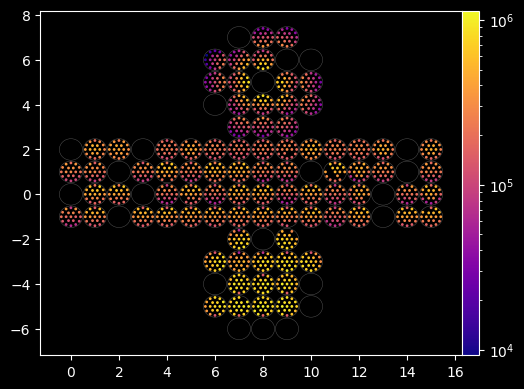

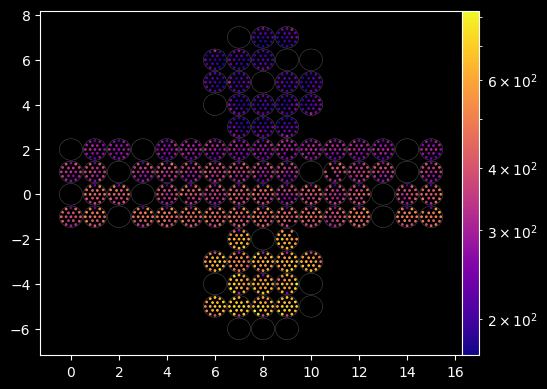

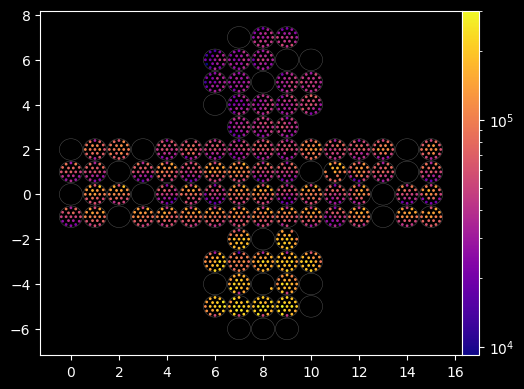

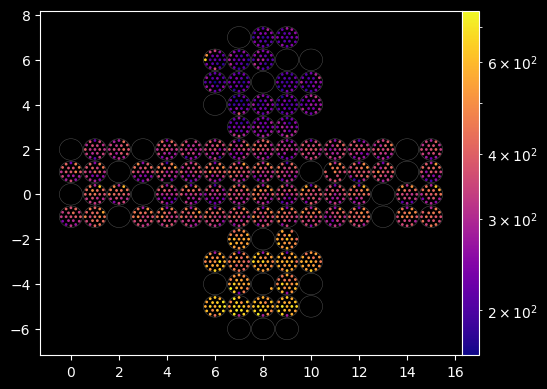

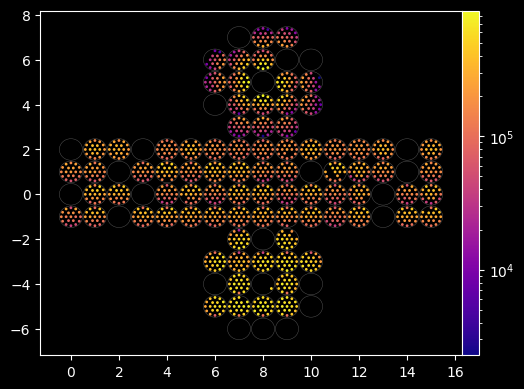

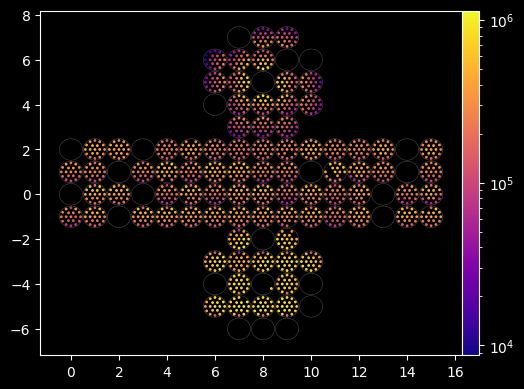

In [36]:
eventDisplay.plotEventDisplay(css,        color_norm=colors.LogNorm(), style= "dark_background")
eventDisplay.plotEventDisplay(css/counts, color_norm=colors.LogNorm(), style= "dark_background")
eventDisplay.plotEventDisplay(cbb,        color_norm=colors.LogNorm(), style= "dark_background")
eventDisplay.plotEventDisplay(cbb/countb, color_norm=colors.LogNorm(), style= "dark_background")
eventDisplay.plotEventDisplay(css-cbb,    color_norm=colors.LogNorm(), style= "dark_background")
eventDisplay.plotEventDisplay(css-cbb/(counts-countb),  color_norm=colors.LogNorm(), style= "dark_background")

plt.style.use('default');
pltext.style()

/tmp/ipykernel_1113463/1280919336.py:10: RuntimeWarning: invalid value encountered in divide
  ax1.step(range(2014), mcss/countmc, where="mid", color="black", label="MC DigiHits Charge")
/tmp/ipykernel_1113463/1280919336.py:23: RuntimeWarning: invalid value encountered in divide
  mc_hits_per_pmt   = N_mc   / countmc


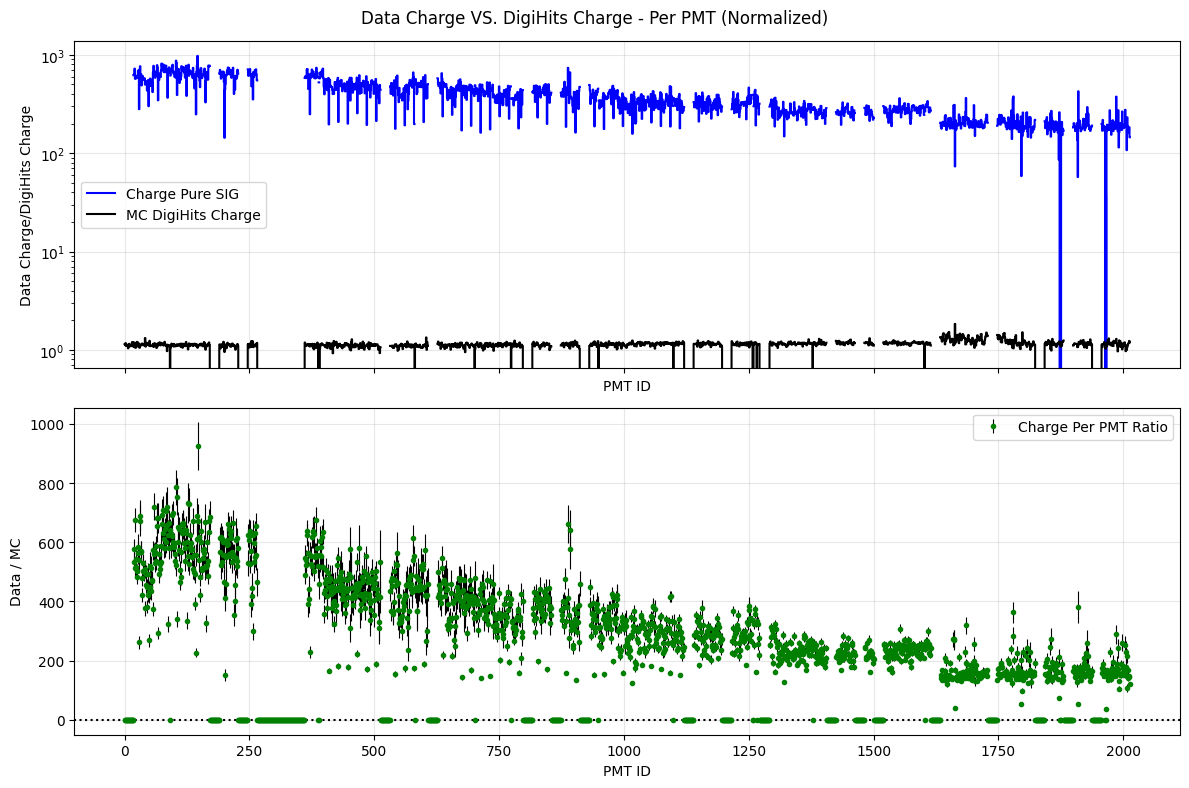

In [37]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2,2]}
)

# --- DigiHits por PMT ---
ax1.step(range(2014), (css-cbb)/(counts-countb), where="mid", color="blue",  label="Charge Pure SIG")
ax1.step(range(2014), mcss/countmc, where="mid", color="black", label="MC DigiHits Charge")

ax1.set_yscale("log")
ax1.set_ylabel("Data Charge/DigiHits Charge")
ax1.set_xlabel("PMT ID")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Hits por PMT normalizados ---
N_data = css-cbb          # conteos por PMT
N_mc   = mcss            # conteos por PMT

data_hits_per_pmt = N_data / (counts-countb)
mc_hits_per_pmt   = N_mc   / countmc

# --- Errores Poissonianos por bin ---
error_data = np.zeros(2014)
error_mc   = np.zeros(2014)

mask_data = N_data > 0
mask_mc   = N_mc   > 0

error_data[mask_data] = np.sqrt(N_data[mask_data]) / (counts-countb)[mask_data]
error_mc[mask_mc]     = np.sqrt(N_mc[mask_mc])   / countmc[mask_mc]

# --- Ratio Data / MC y su error ---
relative_qe       = np.zeros(2014)
error_relative_qe = np.zeros(2014)

mask = (mc_hits_per_pmt > 0) & (data_hits_per_pmt > 0)

relative_qe[mask] = data_hits_per_pmt[mask] / mc_hits_per_pmt[mask]

error_relative_qe[mask] = np.sqrt(
    (error_data[mask] / mc_hits_per_pmt[mask])**2
    +
    (data_hits_per_pmt[mask] * error_mc[mask] / mc_hits_per_pmt[mask]**2)**2
)

ax2.errorbar(
    range(2014),
    relative_qe,
    yerr=error_relative_qe,
    fmt="o",
    markersize=3,
    markerfacecolor="green",
    markeredgecolor="green",
    ecolor="black",        # color de las barras de error
    elinewidth=0.8,
    capsize=0,
    label="Charge Per PMT Ratio"
)
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT ID")
ax2.grid(alpha=0.3)
# ax2.set_ylim(-2, 4)
plt.legend()

plt.suptitle("Data Charge VS. DigiHits Charge - Per PMT (Normalized)", y=0.98)
plt.tight_layout()